#SAM2-OV: detección open-vocabulary



In [ ]:
import torch
print("CUDA disponible:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "⚠️ No hay GPU activada")
device = "cuda" if torch.cuda.is_available() else "cpu"

CUDA disponible: True
GPU: Tesla T4


## 1. Instalación

In [ ]:
!git clone https://github.com/facebookresearch/sam2.git
%cd sam2
!pip install -e . -q
%cd ..
# Fijamos la versión de transformers: las versiones más nuevas (4.5x+/5.x) rompen el código
# personalizado de Florence-2 (error típico: "Florence2LanguageConfig has no attribute forced_bos_token_id").
!pip install -q "transformers==4.49.0" accelerate timm einops sentencepiece

Cloning into 'sam2'...
remote: Enumerating objects: 1107, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 1107 (delta 10), reused 4 (delta 4), pack-reused 1093 (from 2)
Receiving objects: 100% (1107/1107), 134.85 MiB | 32.25 MiB/s, done.
Resolving deltas: 100% (385/385), done.
/content/sam2
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 11.5 MB/s eta 0:00:00
  Building editable for SAM-2 (pyproject.toml) ... done
/content
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 71.4 MB/s eta 0:00:00
   ━━━━

## 2. Descargar el checkpoint de SAM2

In [ ]:
!mkdir -p checkpoints
!wget -q -O checkpoints/sam2.1_hiera_small.pt https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_small.pt
print("✅ Checkpoint descargado.")

✅ Checkpoint descargado.


## 3. Elegir el video


Total de frames: 200


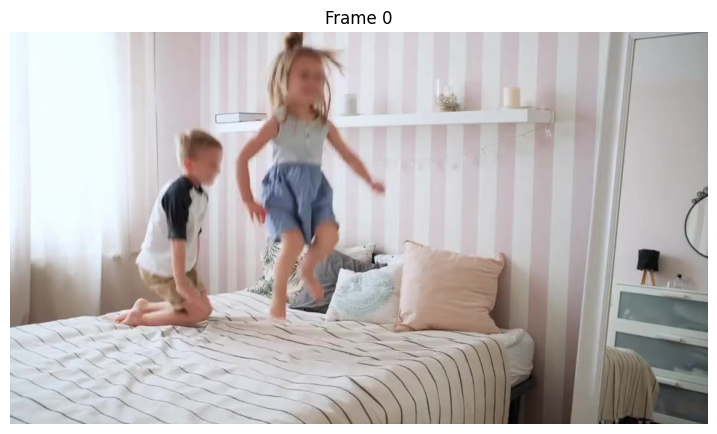

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

VIDEO_SOURCE = "ejemplo"

if VIDEO_SOURCE == "ejemplo":
    video_dir = "sam2/notebooks/videos/bedroom"

elif VIDEO_SOURCE == "subir":
    from google.colab import files
    print("Selecciona tu archivo .mp4...")
    uploaded = files.upload()
    video_filename = list(uploaded.keys())[0]

    video_dir = "mi_video_frames"
    !mkdir -p {video_dir}
    !ffmpeg -y -i "{video_filename}" -q:v 2 -start_number 0 {video_dir}/%05d.jpg -loglevel error

elif VIDEO_SOURCE == "youtube":
    YOUTUBE_URL = "https://www.youtube.com/watch?v=XXXXXXXXXXX"
    CLIP_SECONDS = 15

    !pip install -q yt-dlp
    !yt-dlp -f "bv*[height<=720][ext=mp4]+ba[ext=m4a]/best[ext=mp4]" -o "youtube_video.mp4" "{YOUTUBE_URL}"

    src_video = "youtube_video.mp4"
    if CLIP_SECONDS:
        !ffmpeg -y -i {src_video} -t {CLIP_SECONDS} -c copy youtube_clip.mp4 -loglevel error
        src_video = "youtube_clip.mp4"

    video_dir = "youtube_frames"
    !mkdir -p {video_dir}
    !ffmpeg -y -i {src_video} -q:v 2 -start_number 0 {video_dir}/%05d.jpg -loglevel error

else:
    raise ValueError("VIDEO_SOURCE debe ser 'ejemplo', 'subir' o 'youtube'")

frame_names = [p for p in os.listdir(video_dir) if os.path.splitext(p)[-1].lower() in [".jpg", ".jpeg"]]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))
print(f"Total de frames: {len(frame_names)}")

plt.figure(figsize=(9, 6))
plt.title("Frame 0")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[0])))
plt.axis("off")
plt.show()

In [ ]:
# Funciones auxiliares de visualización (reutilizadas en todo el notebook)

def show_mask(mask, ax, obj_id=None, random_color=False):
    if random_color:
        color = np.concatenate([np.random.random(3), np.array([0.6])], axis=0)
    else:
        cmap = plt.get_cmap("tab10")
        color = np.array([*cmap((obj_id if obj_id is not None else 0) % 10)[:3], 0.6])
    h, w = mask.shape[-2:]
    mask_image = mask.reshape(h, w, 1) * color.reshape(1, 1, -1)
    ax.imshow(mask_image)

def show_box(box, ax, color="lime"):
    x0, y0 = box[0], box[1]
    w, h = box[2] - box[0], box[3] - box[1]
    ax.add_patch(plt.Rectangle((x0, y0), w, h, edgecolor=color, facecolor=(0, 0, 0, 0), lw=2))

## 4. Cargar el detector open-vocabulary

In [ ]:
DETECTOR_CHOICE = "florence2"

if DETECTOR_CHOICE == "florence2":
    from unittest.mock import patch
    from transformers import AutoModelForCausalLM, AutoProcessor
    from transformers.dynamic_module_utils import get_imports

    def fixed_get_imports(filename):
        imports = get_imports(filename)
        if "flash_attn" in imports:
            imports.remove("flash_attn")
        return imports

    model_id = "microsoft/Florence-2-large"
    with patch("transformers.dynamic_module_utils.get_imports", fixed_get_imports):
        det_model = AutoModelForCausalLM.from_pretrained(
            model_id, trust_remote_code=True, torch_dtype=torch.float16
        ).to(device).eval()
    det_processor = AutoProcessor.from_pretrained(model_id, trust_remote_code=True)

elif DETECTOR_CHOICE == "paligemma2":
    from huggingface_hub import notebook_login
    notebook_login()

    from transformers import PaliGemmaForConditionalGeneration, AutoProcessor as PGProcessor

    model_id = "google/paligemma2-3b-mix-448"
    det_processor = PGProcessor.from_pretrained(model_id)
    det_model = PaliGemmaForConditionalGeneration.from_pretrained(
        model_id, torch_dtype=torch.bfloat16
    ).to(device).eval()

print(f"✅ Detector cargado: {DETECTOR_CHOICE}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

configuration_florence2.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- configuration_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_florence2.py: 0.00B [00:00, ?B/s]

...

A new version of the following files was downloaded from https://huggingface.co/microsoft/Florence-2-large:
- processing_florence2.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


tokenizer_config.json:   0%|          | 0.00/34.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Detector cargado: florence2


In [ ]:
import re

def detect_objects(image_pil, text_query):
    """Devuelve una lista de cajas [x1, y1, x2, y2] en píxeles para el texto dado."""
    if DETECTOR_CHOICE == "florence2":
        task_prompt = "<OPEN_VOCABULARY_DETECTION>"
        prompt = task_prompt + text_query
        inputs = det_processor(text=prompt, images=image_pil, return_tensors="pt").to(device, torch.float16)
        with torch.no_grad():
            generated_ids = det_model.generate(
                input_ids=inputs["input_ids"],
                pixel_values=inputs["pixel_values"],
                max_new_tokens=1024,
                num_beams=3,
            )
        generated_text = det_processor.batch_decode(generated_ids, skip_special_tokens=False)[0]
        parsed = det_processor.post_process_generation(
            generated_text, task=task_prompt, image_size=(image_pil.width, image_pil.height)
        )
        return parsed[task_prompt]["bboxes"]

    elif DETECTOR_CHOICE == "paligemma2":
        prompt = f"detect {text_query}"
        inputs = det_processor(text=prompt, images=image_pil, return_tensors="pt").to(device, torch.bfloat16)
        with torch.no_grad():
            output_ids = det_model.generate(**inputs, max_new_tokens=100)
        decoded = det_processor.decode(output_ids[0], skip_special_tokens=True)
        # PaliGemma devuelve <locXXXX> normalizados en una grilla 0-1024, orden y1,x1,y2,x2
        locs = [int(x) for x in re.findall(r"<loc(\d{4})>", decoded)]
        w, h = image_pil.size
        boxes = []
        for i in range(0, len(locs) - 3, 4):
            y1, x1, y2, x2 = locs[i:i + 4]
            boxes.append([x1 / 1024 * w, y1 / 1024 * h, x2 / 1024 * w, y2 / 1024 * h])
        return boxes

## 5. Detectar objetos en el primer frame (por texto)

In [ ]:
text_queries = ["person", "pillow"]

first_frame_pil = Image.open(os.path.join(video_dir, frame_names[0])).convert("RGB")

detections = []  # lista de (box, label)
for query in text_queries:
    boxes = detect_objects(first_frame_pil, query)
    for box in boxes:
        detections.append((box, query))

print(f"Objetos detectados: {len(detections)}")
for box, label in detections:
    print(f"  {label}: {[round(c, 1) for c in box]}")

Objetos detectados: 6
  person: [307.7, 0.3, 518.9, 400.4]
  person: [142.6, 134.2, 296.2, 406.9]
  pillow: [523.7, 287.0, 684.0, 417.2]
  pillow: [322.1, 288.6, 504.5, 369.1]
  pillow: [380.6, 298.9, 515.0, 388.0]
  pillow: [430.6, 316.7, 542.9, 403.7]


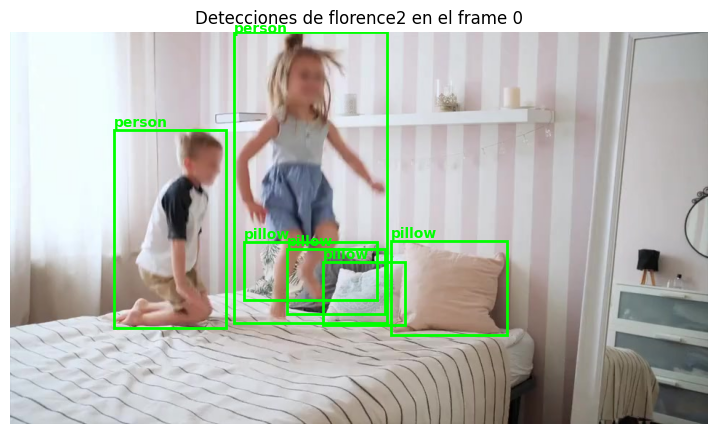

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))
ax.imshow(first_frame_pil)
for box, label in detections:
    show_box(box, ax)
    ax.text(box[0], max(box[1] - 5, 0), label, color="lime", fontsize=10, weight="bold")
ax.axis("off")
ax.set_title(f"Detecciones de {DETECTOR_CHOICE} en el frame 0")
plt.show()

## 6. Cargar el predictor de video de SAM2

In [ ]:
import sys
sys.path.append("sam2")
from sam2.build_sam import build_sam2_video_predictor

sam2_checkpoint = "checkpoints/sam2.1_hiera_small.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_s.yaml"

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device="cuda")
inference_state = predictor.init_state(video_path=video_dir)
print("✅ Predictor de video listo.")

frame loading (JPEG): 100%|██████████| 200/200 [00:07<00:00, 28.48it/s]


✅ Predictor de video listo.


## 7. Convertir las detecciones en prompts para SAM2 y propagar el tracking

In [ ]:
obj_id_to_label = {}

for i, (box, label) in enumerate(detections):
    obj_id = i + 1
    obj_id_to_label[obj_id] = label
    predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=0,
        obj_id=obj_id,
        box=np.array(box, dtype=np.float32),
    )

video_segments = {}
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

print(f"✅ Rastreo propagado a {len(video_segments)} frames, {len(obj_id_to_label)} objeto(s).")

/content/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/content/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 200/200 [06:14<00:00,  1.87s/it]

✅ Rastreo propagado a 200 frames, 6 objeto(s).


## 8. Visualizar una muestra de frames

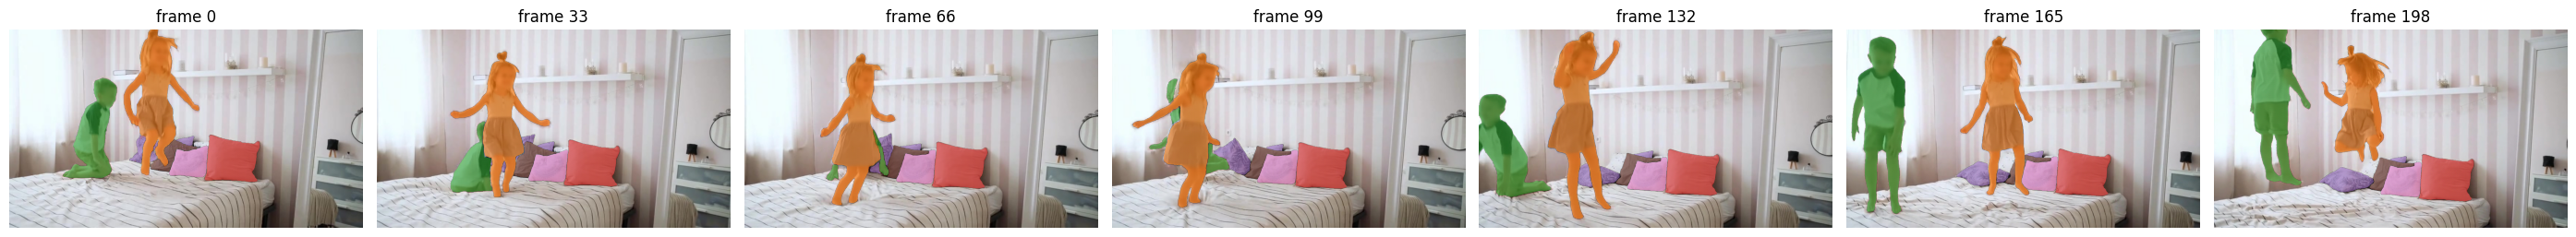

In [ ]:
vis_frame_stride = max(1, len(frame_names) // 6)
sample_idxs = list(range(0, len(frame_names), vis_frame_stride))

fig, axes = plt.subplots(1, len(sample_idxs), figsize=(4 * len(sample_idxs), 4))
for ax, idx in zip(axes, sample_idxs):
    ax.imshow(Image.open(os.path.join(video_dir, frame_names[idx])))
    for obj_id, mask in video_segments[idx].items():
        show_mask(mask, ax, obj_id=obj_id)
    ax.set_title(f"frame {idx}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 9. Guardar el resultado como video (.mp4) con etiquetas

In [ ]:
import cv2

def overlay_mask_cv2(frame_bgr, mask, color=(255, 144, 30), alpha=0.5):
    mask = mask.squeeze().astype(bool)
    out = frame_bgr.copy()
    out[mask] = (out[mask] * (1 - alpha) + np.array(color) * alpha).astype(np.uint8)
    return out

def mask_centroid(mask):
    ys, xs = np.where(mask.squeeze())
    if len(xs) == 0:
        return None
    return int(xs.mean()), int(ys.mean())

first_frame = np.array(first_frame_pil)
height, width = first_frame.shape[:2]

raw_path = "sam2ov_tracking_raw.mp4"
writer = cv2.VideoWriter(raw_path, cv2.VideoWriter_fourcc(*"mp4v"), 24, (width, height))

for idx, name in enumerate(frame_names):
    frame_bgr = cv2.cvtColor(np.array(Image.open(os.path.join(video_dir, name)).convert("RGB")), cv2.COLOR_RGB2BGR)
    for obj_id, mask in video_segments.get(idx, {}).items():
        frame_bgr = overlay_mask_cv2(frame_bgr, mask)
        centroid = mask_centroid(mask)
        if centroid:
            label = obj_id_to_label.get(obj_id, str(obj_id))
            cv2.putText(frame_bgr, f"{label} #{obj_id}", centroid, cv2.FONT_HERSHEY_SIMPLEX,
                        0.6, (255, 255, 255), 2, cv2.LINE_AA)
    writer.write(frame_bgr)

writer.release()

!ffmpeg -y -i {raw_path} -vcodec libx264 -pix_fmt yuv420p sam2ov_tracking_result.mp4 -loglevel error
print("✅ Video guardado: sam2ov_tracking_result.mp4")

from IPython.display import Video
Video("sam2ov_tracking_result.mp4", embed=True, width=600)

✅ Video guardado: sam2ov_tracking_result.mp4


In [ ]:
# Opcional: descargar el video resultante a tu computadora
from google.colab import files
files.download("sam2ov_tracking_result.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>